In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
fire_df = pd.read_csv("../data/raw/data.csv")

fire_df.head()

,Date,District,fireCount
0,2016-04-01,Amritsar,0.0
1,2016-04-01,Barnala,0.0
2,2016-04-01,Bathinda,0.0
3,2016-04-01,Faridkot,0.0
4,2016-04-01,Fatehgarh Sahib,0.0


In [3]:
fire_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 66074 entries, 0 to 66073
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       66074 non-null  str    
 1   District   66074 non-null  str    
 2   fireCount  66074 non-null  float64
dtypes: float64(1), str(2)
memory usage: 1.5 MB


In [4]:
print("Shape:", fire_df.shape)

print("\nNumber of districts:", fire_df["District"].nunique())

print("\nDistricts:")
print(sorted(fire_df["District"].unique()))

Shape: (66074, 3)

Number of districts: 23

Districts:
['Amritsar', 'Barnala', 'Bathinda', 'Faridkot', 'Fatehgarh Sahib', 'Fazilka', 'Firozpur', 'Gurdaspur', 'Hoshiarpur', 'Jalandhar', 'Kapurthala', 'Ludhiana', 'Malerkotla', 'Mansa', 'Moga', 'Muktsar', 'Pathankot', 'Patiala', 'Rupnagar', 'SAS Nagar', 'SBS Nagar', 'Sangrur', 'Tarn Taran']


In [5]:
print("Start date:", fire_df["Date"].min())
print("End date:", fire_df["Date"].max())

Start date: 2016-04-01
End date: 2024-06-05


In [6]:
duplicates = fire_df[fire_df.duplicated(
    subset=["Date", "District"],
    keep=False
)]

print("Rows involved in duplicate Date-District combinations:", len(duplicates))
print("Number of duplicate Date-District combinations:",
      duplicates[["Date", "District"]].drop_duplicates().shape[0])

duplicates.sort_values(["Date", "District"]).head(20)

Rows involved in duplicate Date-District combinations: 470
Number of duplicate Date-District combinations: 234


,Date,District,fireCount
44386,2021-10-09,Malerkotla,1.0
44387,2021-10-09,Malerkotla,0.0
44454,2021-10-12,Malerkotla,1.0
44455,2021-10-12,Malerkotla,0.0
44500,2021-10-14,Malerkotla,2.0
44501,2021-10-14,Malerkotla,0.0
44524,2021-10-15,Malerkotla,3.0
44525,2021-10-15,Malerkotla,0.0
44548,2021-10-16,Malerkotla,2.0
44549,2021-10-16,Malerkotla,0.0


In [7]:
malerkotla = fire_df[fire_df["District"] == "Malerkotla"].copy()

print("Total Malerkotla rows:", len(malerkotla))
print("Start date:", malerkotla["Date"].min())
print("End date:", malerkotla["Date"].max())

print("\nFirst 20 rows:")
print(malerkotla.head(20))

print("\nRows with fireCount > 0:")
print((malerkotla["fireCount"] > 0).sum())

print("\nRows with fireCount == 0:")
print((malerkotla["fireCount"] == 0).sum())

Total Malerkotla rows: 338
Start date: 2021-10-09
End date: 2024-05-31

First 20 rows:
             Date    District  fireCount
44386  2021-10-09  Malerkotla        1.0
44387  2021-10-09  Malerkotla        0.0
44454  2021-10-12  Malerkotla        1.0
44455  2021-10-12  Malerkotla        0.0
44500  2021-10-14  Malerkotla        2.0
44501  2021-10-14  Malerkotla        0.0
44524  2021-10-15  Malerkotla        3.0
44525  2021-10-15  Malerkotla        0.0
44548  2021-10-16  Malerkotla        2.0
44549  2021-10-16  Malerkotla        0.0
44616  2021-10-19  Malerkotla        1.0
44617  2021-10-19  Malerkotla        0.0
44640  2021-10-20  Malerkotla        2.0
44641  2021-10-20  Malerkotla        0.0
44664  2021-10-21  Malerkotla        2.0
44665  2021-10-21  Malerkotla        0.0
44688  2021-10-22  Malerkotla        2.0
44689  2021-10-22  Malerkotla        0.0
44712  2021-10-23  Malerkotla       10.0
44713  2021-10-23  Malerkotla        0.0

Rows with fireCount > 0:
169

Rows with fireCount =

In [8]:
duplicate_groups = (
    fire_df
    .groupby(["Date", "District"])["fireCount"]
    .agg(["count", "sum", "max"])
    .reset_index()
)

duplicate_groups = duplicate_groups[duplicate_groups["count"] > 1]

print("Duplicate groups:", len(duplicate_groups))

print("\nDuplicate groups with MORE THAN ONE non-zero value:")
print(
    fire_df[fire_df["fireCount"] > 0]
    .groupby(["Date", "District"])
    .size()
    .loc[lambda x: x > 1]
)

Duplicate groups: 234

Duplicate groups with MORE THAN ONE non-zero value:
Date        District  
2024-04-30  Barnala       2
            Bathinda      2
            Mansa         2
            SAS Nagar     2
            Sangrur       2
2024-05-31  Bathinda      2
            Gurdaspur     2
            Hoshiarpur    2
            Kapurthala    2
            Malerkotla    2
            Patiala       2
dtype: int64


In [9]:
multi_nonzero = (
    fire_df[fire_df["fireCount"] > 0]
    .groupby(["Date", "District"])
    .size()
)

multi_nonzero = multi_nonzero[multi_nonzero > 1]

problem_rows = fire_df.merge(
    multi_nonzero.reset_index()[["Date", "District"]],
    on=["Date", "District"],
    how="inner"
)

problem_rows.sort_values(["Date", "District"])

,Date,District,fireCount
0,2024-04-30,Barnala,1.0
5,2024-04-30,Barnala,1.0
1,2024-04-30,Bathinda,1.0
6,2024-04-30,Bathinda,5.0
2,2024-04-30,Mansa,2.0
7,2024-04-30,Mansa,3.0
3,2024-04-30,SAS Nagar,2.0
8,2024-04-30,SAS Nagar,1.0
4,2024-04-30,Sangrur,2.0
9,2024-04-30,Sangrur,5.0


In [10]:
duplicate_comparison = (
    fire_df
    .groupby(["Date", "District"])["fireCount"]
    .agg(["count", "sum", "max"])
    .reset_index()
)

duplicate_comparison = duplicate_comparison[
    duplicate_comparison["count"] > 1
]

duplicate_comparison["difference"] = (
    duplicate_comparison["sum"] -
    duplicate_comparison["max"]
)

print("Duplicate groups:", len(duplicate_comparison))

print(
    "\nGroups where SUM and MAX differ:",
    (duplicate_comparison["difference"] > 0).sum()
)

print(
    "\nTotal extra fire count introduced by SUM:",
    duplicate_comparison["difference"].sum()
)

duplicate_comparison.sort_values(
    "difference", ascending=False
).head(15)

Duplicate groups: 234

Groups where SUM and MAX differ: 11

Total extra fire count introduced by SUM: 14.0


,Date,District,count,sum,max,difference
65713,2024-05-31,Hoshiarpur,2,4.0,2.0,2.0
65044,2024-04-30,Sangrur,2,7.0,5.0,2.0
65036,2024-04-30,Mansa,2,5.0,3.0,2.0
65715,2024-05-31,Kapurthala,2,3.0,2.0,1.0
65707,2024-05-31,Bathinda,2,9.0,8.0,1.0
65042,2024-04-30,SAS Nagar,2,3.0,2.0,1.0
65025,2024-04-30,Barnala,2,2.0,1.0,1.0
65712,2024-05-31,Gurdaspur,2,3.0,2.0,1.0
65722,2024-05-31,Patiala,2,3.0,2.0,1.0
65026,2024-04-30,Bathinda,2,6.0,5.0,1.0


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fire_df = pd.read_csv("../data/raw/data.csv")
print(fire_df.shape)

(66074, 3)


In [12]:
fire_clean = fire_df.copy()

In [13]:
fire_clean["Date"] = pd.to_datetime(fire_clean["Date"])

In [14]:
fire_clean = (
    fire_clean
    .groupby(["Date", "District"], as_index=False)["fireCount"]
    .max()
)

In [15]:
print("Original rows:", len(fire_df))
print("Cleaned rows:", len(fire_clean))

print("\nDuplicate Date-District combinations after cleaning:",
      fire_clean.duplicated(["Date", "District"]).sum())

print("\nData types:")
print(fire_clean.dtypes)

Original rows: 66074
Cleaned rows: 65838

Duplicate Date-District combinations after cleaning: 0

Data types:
Date         datetime64[us]
District                str
fireCount           float64
dtype: object


In [16]:
fire_clean.to_csv(
    "../data/processed/cleaned_fire.csv",
    index=False
)

In [17]:
import os

print(os.path.exists("../data/processed/cleaned_fire.csv"))

True


In [18]:
fire_clean.head()

,Date,District,fireCount
0,2016-04-01,Amritsar,0.0
1,2016-04-01,Barnala,0.0
2,2016-04-01,Bathinda,0.0
3,2016-04-01,Faridkot,0.0
4,2016-04-01,Fatehgarh Sahib,0.0


In [19]:
fire_clean.tail()

,Date,District,fireCount
65833,2024-06-05,Rupnagar,0.0
65834,2024-06-05,SAS Nagar,0.0
65835,2024-06-05,SBS Nagar,0.0
65836,2024-06-05,Sangrur,0.0
65837,2024-06-05,Tarn Taran,0.0


In [20]:
print("Fire Count Statistics:")
print(fire_clean["fireCount"].describe())

print("\nZero-fire rows:")
print((fire_clean["fireCount"] == 0).sum())

print("\nNon-zero fire rows:")
print((fire_clean["fireCount"] > 0).sum())

print("\nPercentage of zero-fire rows:")
print(
    round(
        (fire_clean["fireCount"] == 0).mean() * 100,
        2
    ),
    "%"
)

Fire Count Statistics:
count    65838.000000
mean         8.744965
std         42.175184
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       1007.000000
Name: fireCount, dtype: float64

Zero-fire rows:
53298

Non-zero fire rows:
12540

Percentage of zero-fire rows:
80.95 %


In [21]:
district_fire = (
    fire_clean
    .groupby("District")["fireCount"]
    .sum()
    .sort_values(ascending=False)
)

district_fire

District
Sangrur            65401.0
Firozpur           49681.0
Bathinda           48741.0
Moga               42735.0
Muktsar            38595.0
Ludhiana           38353.0
Patiala            36847.0
Tarn Taran         33913.0
Mansa              31546.0
Barnala            30778.0
Faridkot           27232.0
Amritsar           22758.0
Fazilka            22748.0
Jalandhar          20303.0
Gurdaspur          18600.0
Kapurthala         16014.0
Fatehgarh Sahib    11348.0
Hoshiarpur          6327.0
SBS Nagar           5004.0
Malerkotla          3019.0
Rupnagar            2503.0
SAS Nagar           1951.0
Pathankot           1354.0
Name: fireCount, dtype: float64

In [22]:
fire_clean["month"] = fire_clean["Date"].dt.month

monthly_fire = (
    fire_clean
    .groupby("month")["fireCount"]
    .sum()
)

monthly_fire

month
1          0.0
2          0.0
3          0.0
4       8970.0
5     100076.0
6          0.0
7          0.0
8          0.0
9       1693.0
10    164286.0
11    300726.0
12         0.0
Name: fireCount, dtype: float64

In [23]:
monthly_fire_avg = (
    fire_clean
    .groupby("month")["fireCount"]
    .mean()
)

monthly_fire_avg

month
1      0.000000
2      0.000000
3      0.000000
4      1.513158
5     16.219773
6      0.000000
7      0.000000
8      0.000000
9      0.320644
10    29.891921
11    56.273578
12     0.000000
Name: fireCount, dtype: float64

In [24]:
monthly_percentage = (
    monthly_fire / monthly_fire.sum() * 100
).round(2)

monthly_percentage

month
1      0.00
2      0.00
3      0.00
4      1.56
5     17.38
6      0.00
7      0.00
8      0.00
9      0.29
10    28.53
11    52.23
12     0.00
Name: fireCount, dtype: float64

In [25]:
print(
    "October + November contribution:",
    round(
        monthly_percentage.loc[[10, 11]].sum(),
        2
    ),
    "%"
)

October + November contribution: 80.76 %


In [26]:
fire_clean["year"] = fire_clean["Date"].dt.year

yearly_fire = (
    fire_clean
    .groupby("year")["fireCount"]
    .sum()
)

yearly_fire

year
2016    91774.0
2017    59820.0
2018    61497.0
2019    66911.0
2020    90010.0
2021    81404.0
2022    64433.0
2023    48016.0
2024    11886.0
Name: fireCount, dtype: float64

In [27]:
district_coverage = (
    fire_clean
    .groupby("District")["Date"]
    .agg(["min", "max", "count"])
    .sort_values("count")
)

district_coverage

,min,max,count
District,,,
Malerkotla,2021-10-09,2024-05-31,168
Amritsar,2016-04-01,2024-06-05,2985
Bathinda,2016-04-01,2024-06-05,2985
Barnala,2016-04-01,2024-06-05,2985
Fatehgarh Sahib,2016-04-01,2024-06-05,2985
Fazilka,2016-04-01,2024-06-05,2985
Firozpur,2016-04-01,2024-06-05,2985
Faridkot,2016-04-01,2024-06-05,2985
Gurdaspur,2016-04-01,2024-06-05,2985


# 02 - AQI Dataset Exploration

In [28]:
aqi_df = pd.read_csv("../data/raw/city_day.csv")

aqi_df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [29]:
aqi_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  str    
dtypes: float64(13), str(3)
memory usage: 3.6 MB


In [30]:
print("Shape:", aqi_df.shape)

print("\nNumber of cities:", aqi_df["City"].nunique())

print("\nCities:")
print(sorted(aqi_df["City"].unique()))

Shape: (29531, 16)

Number of cities: 26

Cities:
['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru', 'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad', 'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai', 'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram', 'Visakhapatnam']


In [31]:
print("Start date:", aqi_df["Date"].min())
print("End date:", aqi_df["Date"].max())

Start date: 2015-01-01
End date: 2020-07-01


In [32]:
missing = aqi_df.isnull().sum()

print(missing[missing > 0].sort_values(ascending=False))

Xylene        18109
PM10          11140
NH3           10328
Toluene        8041
Benzene        5623
AQI            4681
AQI_Bucket     4681
PM2.5          4598
NOx            4185
O3             4022
SO2            3854
NO2            3585
NO             3582
CO             2059
dtype: int64


In [33]:
print(sorted(aqi_df["City"].unique()))

['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru', 'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad', 'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai', 'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram', 'Visakhapatnam']


In [34]:
city_aqi = (
    aqi_df
    .groupby("City")["AQI"]
    .agg(
        total_rows="size",
        aqi_available="count"
    )
)

city_aqi["aqi_missing"] = (
    city_aqi["total_rows"] -
    city_aqi["aqi_available"]
)

city_aqi["aqi_available_pct"] = (
    city_aqi["aqi_available"] /
    city_aqi["total_rows"] * 100
).round(2)

city_aqi.sort_values("aqi_available_pct")

,total_rows,aqi_available,aqi_missing,aqi_available_pct
City,,,,
Mumbai,2009,775,1234,38.58
Jorapokhar,1169,771,398,65.95
Shillong,310,205,105,66.13
Ahmedabad,2009,1334,675,66.40
Talcher,925,698,227,75.46
Brajrajnagar,938,713,225,76.01
Patna,1858,1459,399,78.53
Visakhapatnam,1462,1171,291,80.10
Gurugram,1679,1453,226,86.54


In [35]:
print(aqi_df["AQI"].describe())

count    24850.000000
mean       166.463581
std        140.696585
min         13.000000
25%         81.000000
50%        118.000000
75%        208.000000
max       2049.000000
Name: AQI, dtype: float64


In [36]:
print(
    "Duplicate City-Date rows:",
    aqi_df.duplicated(["City", "Date"]).sum()
)

Duplicate City-Date rows: 0


# 03 - AQI Station Dataset Exploration

In [37]:
station_aqi_df = pd.read_csv("../data/raw/aqi.csv")

station_aqi_df.head()

,date,state,area,number_of_monitoring_stations,prominent_pollutants,aqi_value,air_quality_status,unit,note
0,30-04-2025,Maharashtra,Amravati,2,PM10,78,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
1,30-04-2025,Bihar,Purnia,1,CO,56,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
2,30-04-2025,Madhya Pradesh,Katni,1,O3,98,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
3,30-04-2025,Chhattisgarh,Tumidih,1,PM10,103,Moderate,number_of_monitoring_stations in Absolute Numb...,NaN
4,30-04-2025,Assam,Byrnihat,1,PM2.5,61,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN


In [38]:
station_aqi_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 235785 entries, 0 to 235784
Data columns (total 9 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   date                           235785 non-null  str    
 1   state                          235785 non-null  str    
 2   area                           235785 non-null  str    
 3   number_of_monitoring_stations  235785 non-null  int64  
 4   prominent_pollutants           235785 non-null  str    
 5   aqi_value                      235785 non-null  int64  
 6   air_quality_status             235785 non-null  str    
 7   unit                           235785 non-null  str    
 8   note                           0 non-null       float64
dtypes: float64(1), int64(2), str(6)
memory usage: 16.2 MB


In [39]:
print("Shape:", station_aqi_df.shape)
print("\nColumns:")
print(station_aqi_df.columns.tolist())

Shape: (235785, 9)

Columns:
['date', 'state', 'area', 'number_of_monitoring_stations', 'prominent_pollutants', 'aqi_value', 'air_quality_status', 'unit', 'note']


In [40]:
station_aqi_df.isnull().sum().sort_values(ascending=False)

note                             235785
date                                  0
state                                 0
number_of_monitoring_stations         0
area                                  0
prominent_pollutants                  0
aqi_value                             0
air_quality_status                    0
unit                                  0
dtype: int64

In [41]:
print(station_aqi_df.head(20))

          date           state          area  number_of_monitoring_stations  \
0   30-04-2025     Maharashtra      Amravati                              2   
1   30-04-2025           Bihar        Purnia                              1   
2   30-04-2025  Madhya Pradesh         Katni                              1   
3   30-04-2025    Chhattisgarh       Tumidih                              1   
4   30-04-2025           Assam      Byrnihat                              1   
5   30-04-2025         Manipur        Imphal                              1   
6   30-04-2025          Kerala        Kollam                              1   
7   30-04-2025     West Bengal   Barrackpore                              1   
8   30-04-2025          Odisha      Nayagarh                              1   
9   30-04-2025           Assam       Nalbari                              1   
10  30-04-2025       Karnataka      Hubballi                              1   
11  30-04-2025         Gujarat     Ahmedabad        

In [42]:
print(station_aqi_df.columns.tolist())

['date', 'state', 'area', 'number_of_monitoring_stations', 'prominent_pollutants', 'aqi_value', 'air_quality_status', 'unit', 'note']


In [43]:
station_aqi_df.head()

,date,state,area,number_of_monitoring_stations,prominent_pollutants,aqi_value,air_quality_status,unit,note
0,30-04-2025,Maharashtra,Amravati,2,PM10,78,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
1,30-04-2025,Bihar,Purnia,1,CO,56,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
2,30-04-2025,Madhya Pradesh,Katni,1,O3,98,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN
3,30-04-2025,Chhattisgarh,Tumidih,1,PM10,103,Moderate,number_of_monitoring_stations in Absolute Numb...,NaN
4,30-04-2025,Assam,Byrnihat,1,PM2.5,61,Satisfactory,number_of_monitoring_stations in Absolute Numb...,NaN


In [44]:
station_aqi_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 235785 entries, 0 to 235784
Data columns (total 9 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   date                           235785 non-null  str    
 1   state                          235785 non-null  str    
 2   area                           235785 non-null  str    
 3   number_of_monitoring_stations  235785 non-null  int64  
 4   prominent_pollutants           235785 non-null  str    
 5   aqi_value                      235785 non-null  int64  
 6   air_quality_status             235785 non-null  str    
 7   unit                           235785 non-null  str    
 8   note                           0 non-null       float64
dtypes: float64(1), int64(2), str(6)
memory usage: 16.2 MB


In [45]:
print("Shape:", station_aqi_df.shape)

Shape: (235785, 9)


In [46]:
station_aqi_df["date"] = pd.to_datetime(
    station_aqi_df["date"],
    dayfirst=True
)

print("Start date:", station_aqi_df["date"].min())
print("End date:", station_aqi_df["date"].max())

Start date: 2022-04-01 00:00:00
End date: 2025-04-30 00:00:00


In [47]:
print(
    station_aqi_df[
        station_aqi_df["state"].str.contains(
            "Punjab",
            case=False,
            na=False
        )
    ]["area"].unique()
)

<StringArray>
[       'Jalandhar',          'Patiala',         'Ludhiana',
         'Bathinda',           'Khanna', 'Mandi Gobindgarh',
         'Amritsar',         'Rupnagar']
Length: 8, dtype: str


In [48]:
print("Number of states:", station_aqi_df["state"].nunique())

print("\nStates:")
print(sorted(station_aqi_df["state"].dropna().unique()))

Number of states: 32

States:
['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Delhi', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


In [49]:
punjab_aqi = station_aqi_df[
    station_aqi_df["state"] == "Punjab"
].copy()

print("Punjab AQI rows:", len(punjab_aqi))

print("\nAreas:")
print(sorted(punjab_aqi["area"].unique()))

Punjab AQI rows: 8488

Areas:
['Amritsar', 'Bathinda', 'Jalandhar', 'Khanna', 'Ludhiana', 'Mandi Gobindgarh', 'Patiala', 'Rupnagar']


In [50]:
print("\nAQI statistics:")
print(punjab_aqi["aqi_value"].describe())


AQI statistics:
count    8488.000000
mean      117.854265
std        59.304512
min        14.000000
25%        75.000000
50%       104.000000
75%       146.000000
max       417.000000
Name: aqi_value, dtype: float64


In [51]:
punjab_coverage = (
    punjab_aqi
    .groupby("area")["date"]
    .agg(["min", "max", "count"])
    .sort_values("count", ascending=False)
)

punjab_coverage

,min,max,count
area,,,
Ludhiana,2022-04-01,2025-04-30,1112
Patiala,2022-04-01,2025-04-30,1110
Jalandhar,2022-04-01,2025-04-30,1107
Khanna,2022-04-01,2025-04-30,1100
Amritsar,2022-04-01,2025-04-24,1041
Mandi Gobindgarh,2022-04-01,2025-04-27,1010
Bathinda,2022-04-01,2025-04-30,1009
Rupnagar,2022-04-01,2025-04-21,999


In [52]:
print(
    "Duplicate Area-Date rows:",
    punjab_aqi.duplicated(["date", "area"]).sum()
)

Duplicate Area-Date rows: 0


In [53]:
aqi_clean = punjab_aqi.copy()

In [54]:
aqi_clean[
    [
        "date",
        "state",
        "area",
        "number_of_monitoring_stations",
        "prominent_pollutants",
        "aqi_value",
        "air_quality_status"
    ]
].head()

,date,state,area,number_of_monitoring_stations,prominent_pollutants,aqi_value,air_quality_status
46,2025-04-30,Punjab,Jalandhar,1,PM2.5,138,Moderate
49,2025-04-30,Punjab,Patiala,1,PM10,118,Moderate
109,2025-04-30,Punjab,Ludhiana,1,PM10,72,Satisfactory
123,2025-04-30,Punjab,Bathinda,1,PM10,154,Moderate
154,2025-04-30,Punjab,Khanna,1,PM10,120,Moderate


In [55]:
aqi_clean.isnull().sum()

date                                0
state                               0
area                                0
number_of_monitoring_stations       0
prominent_pollutants                0
aqi_value                           0
air_quality_status                  0
unit                                0
note                             8488
dtype: int64

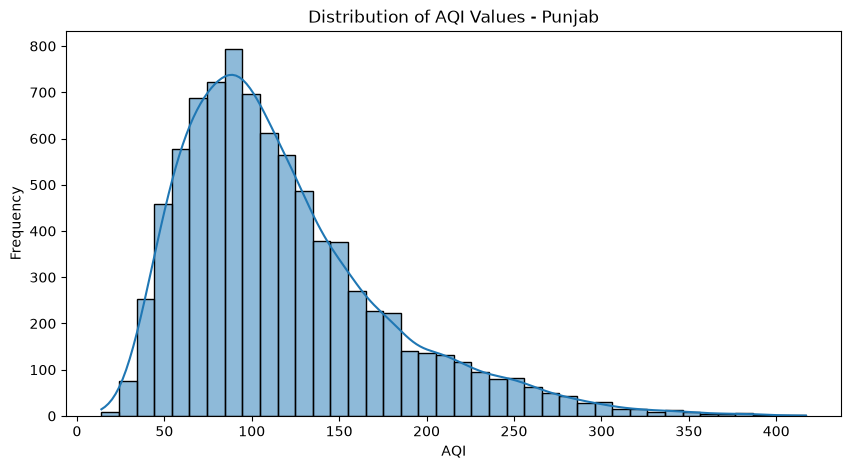

In [56]:
plt.figure(figsize=(10, 5))

sns.histplot(
    aqi_clean["aqi_value"],
    bins=40,
    kde=True
)

plt.title("Distribution of AQI Values - Punjab")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()

In [57]:
print(aqi_clean["air_quality_status"].value_counts())

air_quality_status
Moderate        3649
Satisfactory    3384
Poor             777
Good             583
Very Poor         93
Severe             2
Name: count, dtype: int64


In [58]:
aqi_clean["date"].dtype

dtype('<M8[us]')

In [59]:
aqi_clean.to_csv(
    "../data/processed/cleaned_punjab_aqi.csv",
    index=False
)

In [60]:
import os

print(
    os.path.exists(
        "../data/processed/cleaned_punjab_aqi.csv"
    )
)

True


In [61]:
target_areas = [
    "Amritsar",
    "Bathinda",
    "Jalandhar",
    "Ludhiana",
    "Patiala",
    "Rupnagar"
]

aqi_model = aqi_clean[
    aqi_clean["area"].isin(target_areas)
].copy()

print("Rows:", len(aqi_model))
print("\nAreas:")
print(aqi_model["area"].value_counts())

Rows: 6378

Areas:
area
Ludhiana     1112
Patiala      1110
Jalandhar    1107
Amritsar     1041
Bathinda     1009
Rupnagar      999
Name: count, dtype: int64


In [62]:
aqi_model = aqi_model[
    (aqi_model["date"] >= "2022-04-01") &
    (aqi_model["date"] <= "2024-06-05")
].copy()

print("Rows after date filtering:", len(aqi_model))

print(
    "\nDate range:",
    aqi_model["date"].min(),
    "→",
    aqi_model["date"].max()
)

Rows after date filtering: 4518

Date range: 2022-04-01 00:00:00 → 2024-06-05 00:00:00


In [65]:
fire_model = fire_clean[
    (fire_clean["District"].isin(target_areas)) &
    (fire_clean["Date"] >= "2022-04-01") &
    (fire_clean["Date"] <= "2024-06-05")
].copy()

print("Fire rows:", len(fire_model))

print("\nDistricts:")
print(fire_model["District"].value_counts())

Fire rows: 4764

Districts:
District
Amritsar     794
Bathinda     794
Jalandhar    794
Ludhiana     794
Patiala      794
Rupnagar     794
Name: count, dtype: int64


In [66]:
fire_model = fire_model.rename(
    columns={"District": "area"}
)

In [67]:
fire_model = fire_model.rename(
    columns={"Date": "date"}
)

In [68]:
print(fire_model[["date", "area", "fireCount"]].head())

            date       area  fireCount
48237 2022-04-01   Amritsar        0.0
48239 2022-04-01   Bathinda        0.0
48246 2022-04-01  Jalandhar        0.0
48248 2022-04-01   Ludhiana        0.0
48253 2022-04-01    Patiala        0.0


In [69]:
print("AQI rows:", len(aqi_model))

AQI rows: 4518


In [70]:
print("Fire rows:", len(fire_model))

Fire rows: 4764


In [71]:
print(
    "Unique Fire Date-Area combinations:",
    fire_model[["date", "area"]].drop_duplicates().shape[0]
)

print(
    "Unique AQI Date-Area combinations:",
    aqi_model[["date", "area"]].drop_duplicates().shape[0]
)

Unique Fire Date-Area combinations: 4764
Unique AQI Date-Area combinations: 4518


In [73]:
merged_check = pd.merge(
    aqi_model,
    fire_model[["date", "area", "fireCount"]],
    on=["date", "area"],
    how="outer",
    indicator=True
)

print(merged_check["_merge"].value_counts())

_merge
both          4500
right_only     264
left_only       18
Name: count, dtype: int64


In [74]:
model_base = merged_check[
    merged_check["_merge"] == "both"
].drop(columns=["_merge"])

In [75]:
print("Final matched rows:", len(model_base))

print("\nAreas:")
print(model_base["area"].value_counts())

print("\nDate range:")
print(model_base["date"].min(), "→", model_base["date"].max())

Final matched rows: 4500

Areas:
area
Ludhiana     785
Patiala      784
Jalandhar    780
Amritsar     730
Rupnagar     716
Bathinda     705
Name: count, dtype: int64

Date range:
2022-04-01 00:00:00 → 2024-06-05 00:00:00


In [76]:
model_base.to_csv(
    "../data/processed/model_base.csv",
    index=False
)

In [77]:
print(
    os.path.exists(
        "../data/processed/model_base.csv"
    )
)

True


# 04 - Weather Data Integration

In [78]:
import requests
import pandas as pd

In [80]:
locations = {
    "Amritsar": (31.6340, 74.8723),
    "Bathinda": (30.2110, 74.9455),
    "Jalandhar": (31.3260, 75.5762),
    "Ludhiana": (30.9010, 75.8573),
    "Patiala": (30.3398, 76.3869),
    "Rupnagar": (30.9660, 76.5330)
}

In [81]:
latitude, longitude = locations["Amritsar"]

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": "2022-04-01",
    "end_date": "2022-04-07",
    "daily": ",".join([
        "temperature_2m_mean",
        "temperature_2m_max",
        "temperature_2m_min",
        "relative_humidity_2m_mean",
        "precipitation_sum",
        "wind_speed_10m_max",
        "surface_pressure_mean"
    ]),
    "timezone": "Asia/Kolkata",
    "temperature_unit": "celsius",
    "wind_speed_unit": "kmh",
    "precipitation_unit": "mm"
}

response = requests.get(url, params=params)

print("Status code:", response.status_code)

Status code: 200


In [82]:
weather_test = response.json()

print(weather_test.keys())

dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'daily_units', 'daily'])


In [83]:
weather_test_df = pd.DataFrame(
    weather_test["daily"]
)

weather_test_df

,time,temperature_2m_mean,temperature_2m_max,temperature_2m_min,relative_humidity_2m_mean,precipitation_sum,wind_speed_10m_max,surface_pressure_mean
0,2022-04-01,25.2,33.2,17.5,40,0.0,11.5,980.0
1,2022-04-02,24.5,33.7,16.2,51,0.0,13.0,980.5
2,2022-04-03,24.7,33.5,18.3,51,0.0,12.8,980.7
3,2022-04-04,25.8,35.1,16.9,44,0.0,10.4,980.9
4,2022-04-05,27.9,35.3,18.9,36,0.0,8.6,983.6
5,2022-04-06,27.5,36.0,17.6,38,0.0,10.8,983.3
6,2022-04-07,27.8,37.4,19.4,36,0.0,13.0,982.4


In [84]:
def get_weather_data(city, latitude, longitude, start_date, end_date):

    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "daily": ",".join([
            "temperature_2m_mean",
            "temperature_2m_max",
            "temperature_2m_min",
            "relative_humidity_2m_mean",
            "precipitation_sum",
            "wind_speed_10m_max",
            "surface_pressure_mean"
        ]),
        "timezone": "Asia/Kolkata",
        "temperature_unit": "celsius",
        "wind_speed_unit": "kmh",
        "precipitation_unit": "mm"
    }

    response = requests.get(url, params=params)

    if response.status_code != 200:
        print(f"Failed for {city}: {response.status_code}")
        return None

    data = response.json()

    weather_df = pd.DataFrame(data["daily"])

    weather_df["area"] = city

    return weather_df

In [85]:
amritsar_weather = get_weather_data(
    "Amritsar",
    *locations["Amritsar"],
    "2022-04-01",
    "2024-06-05"
)

amritsar_weather.head()

,time,temperature_2m_mean,temperature_2m_max,temperature_2m_min,relative_humidity_2m_mean,precipitation_sum,wind_speed_10m_max,surface_pressure_mean,area
0,2022-04-01,25.2,33.2,17.5,40,0.0,11.5,980.0,Amritsar
1,2022-04-02,24.5,33.7,16.2,51,0.0,13.0,980.5,Amritsar
2,2022-04-03,24.7,33.5,18.3,51,0.0,12.8,980.7,Amritsar
3,2022-04-04,25.8,35.1,16.9,44,0.0,10.4,980.9,Amritsar
4,2022-04-05,27.9,35.3,18.9,36,0.0,8.6,983.6,Amritsar


In [86]:
print(amritsar_weather.shape)
print(amritsar_weather.tail())

(797, 9)
           time  temperature_2m_mean  temperature_2m_max  temperature_2m_min  \
792  2024-06-01                 35.6                44.4                26.5   
793  2024-06-02                 35.6                42.8                27.7   
794  2024-06-03                 37.0                44.8                29.5   
795  2024-06-04                 34.9                44.0                28.2   
796  2024-06-05                 32.3                40.4                26.9   

     relative_humidity_2m_mean  precipitation_sum  wind_speed_10m_max  \
792                         16                0.0                21.7   
793                         21                0.0                16.8   
794                         18                0.0                15.7   
795                         24                1.1                28.5   
796                         34                0.3                24.8   

     surface_pressure_mean      area  
792                  973.7  Amri

In [87]:
weather_data = []

for city, (latitude, longitude) in locations.items():

    print(f"Fetching weather for {city}...")

    city_weather = get_weather_data(
        city,
        latitude,
        longitude,
        "2022-04-01",
        "2024-06-05"
    )

    if city_weather is not None:
        weather_data.append(city_weather)

weather_df = pd.concat(
    weather_data,
    ignore_index=True
)

print("\nFinal weather shape:", weather_df.shape)

Fetching weather for Amritsar...
Fetching weather for Bathinda...
Fetching weather for Jalandhar...
Fetching weather for Ludhiana...
Fetching weather for Patiala...
Fetching weather for Rupnagar...

Final weather shape: (4782, 9)


In [88]:
print(weather_df["area"].value_counts())

area
Amritsar     797
Bathinda     797
Jalandhar    797
Ludhiana     797
Patiala      797
Rupnagar     797
Name: count, dtype: int64


In [89]:
print(
    weather_df["time"].min(),
    "→",
    weather_df["time"].max()
)

2022-04-01 → 2024-06-05


In [90]:
weather_df = weather_df.rename(
    columns={"time": "date"}
)

weather_df["date"] = pd.to_datetime(
    weather_df["date"]
)

In [91]:
weather_df.head()

,date,temperature_2m_mean,temperature_2m_max,temperature_2m_min,relative_humidity_2m_mean,precipitation_sum,wind_speed_10m_max,surface_pressure_mean,area
0,2022-04-01,25.2,33.2,17.5,40,0.0,11.5,980.0,Amritsar
1,2022-04-02,24.5,33.7,16.2,51,0.0,13.0,980.5,Amritsar
2,2022-04-03,24.7,33.5,18.3,51,0.0,12.8,980.7,Amritsar
3,2022-04-04,25.8,35.1,16.9,44,0.0,10.4,980.9,Amritsar
4,2022-04-05,27.9,35.3,18.9,36,0.0,8.6,983.6,Amritsar


In [92]:
weather_df.to_csv(
    "../data/external/weather_data.csv",
    index=False
)

In [93]:
print(
    os.path.exists(
        "../data/external/weather_data.csv"
    )
)

True


In [94]:
weather_df.isnull().sum()

date                         0
temperature_2m_mean          0
temperature_2m_max           0
temperature_2m_min           0
relative_humidity_2m_mean    0
precipitation_sum            0
wind_speed_10m_max           0
surface_pressure_mean        0
area                         0
dtype: int64

In [95]:
weather_df.describe()

,date,temperature_2m_mean,temperature_2m_max,temperature_2m_min,relative_humidity_2m_mean,precipitation_sum,wind_speed_10m_max,surface_pressure_mean
count,4782,4782.00000,4782.000000,4782.000000,4782.000000,4782.000000,4782.000000,4782.000000
mean,2023-05-04 00:00:00,23.37478,29.874132,17.828649,65.261188,2.034212,13.785696,980.918151
min,2022-04-01 00:00:00,6.40000,11.600000,0.500000,13.000000,0.000000,4.800000,963.800000
25%,2022-10-17 00:00:00,17.40000,24.400000,11.500000,54.000000,0.000000,10.200000,975.400000
50%,2023-05-04 00:00:00,25.40000,31.400000,19.000000,70.000000,0.000000,12.600000,980.700000
75%,2023-11-19 00:00:00,29.20000,34.600000,24.700000,80.000000,0.500000,16.300000,986.400000
max,2024-06-05 00:00:00,37.60000,46.200000,31.800000,95.000000,123.300000,38.200000,999.400000
std,NaN,7.45657,7.331019,7.426678,19.569326,6.657261,4.821990,6.742607


In [96]:
print(
    "Duplicate Date-Area rows:",
    weather_df.duplicated(["date", "area"]).sum()
)

Duplicate Date-Area rows: 0


In [97]:
final_df = pd.merge(
    model_base,
    weather_df,
    on=["date", "area"],
    how="inner"
)

print("Final dataset shape:", final_df.shape)

Final dataset shape: (4500, 17)


In [98]:
print(final_df.head())

        date   state       area  number_of_monitoring_stations  \
0 2022-04-01  Punjab   Amritsar                            1.0   
1 2022-04-01  Punjab   Bathinda                            1.0   
2 2022-04-01  Punjab  Jalandhar                            1.0   
3 2022-04-01  Punjab   Ludhiana                            1.0   
4 2022-04-01  Punjab    Patiala                            1.0   

  prominent_pollutants  aqi_value air_quality_status  \
0                 PM10      101.0           Moderate   
1                 PM10       60.0       Satisfactory   
2                 PM10      117.0           Moderate   
3                 PM10      126.0           Moderate   
4                 PM10      130.0           Moderate   

                                                unit  note  fireCount  \
0  number_of_monitoring_stations in Absolute Numb...   NaN        0.0   
1  number_of_monitoring_stations in Absolute Numb...   NaN        0.0   
2  number_of_monitoring_stations in Absolute Nu

In [99]:
print("\nMissing values:")
print(final_df.isnull().sum())


Missing values:
date                                0
state                               0
area                                0
number_of_monitoring_stations       0
prominent_pollutants                0
aqi_value                           0
air_quality_status                  0
unit                                0
note                             4500
fireCount                           0
temperature_2m_mean                 0
temperature_2m_max                  0
temperature_2m_min                  0
relative_humidity_2m_mean           0
precipitation_sum                   0
wind_speed_10m_max                  0
surface_pressure_mean               0
dtype: int64


In [100]:
print("\nAreas:")
print(final_df["area"].value_counts())

print("\nDate range:")
print(final_df["date"].min(), "→", final_df["date"].max())


Areas:
area
Ludhiana     785
Patiala      784
Jalandhar    780
Amritsar     730
Rupnagar     716
Bathinda     705
Name: count, dtype: int64

Date range:
2022-04-01 00:00:00 → 2024-06-05 00:00:00


In [101]:
final_df.to_csv(
    "../data/processed/final_merged_dataset.csv",
    index=False
)

print("Saved successfully:", 
      os.path.exists("../data/processed/final_merged_dataset.csv"))

Saved successfully: True


In [102]:
print("Unique values:")

print("\nState:")
print(final_df["state"].unique())

print("\nMonitoring stations:")
print(final_df["number_of_monitoring_stations"].value_counts())

print("\nUnit:")
print(final_df["unit"].unique())

print("\nProminent pollutants:")
print(final_df["prominent_pollutants"].value_counts())

Unique values:

State:
<StringArray>
['Punjab']
Length: 1, dtype: str

Monitoring stations:
number_of_monitoring_stations
1.0    4500
Name: count, dtype: int64

Unit:
<StringArray>
['number_of_monitoring_stations in Absolute Number, aqi_value in Indices']
Length: 1, dtype: str

Prominent pollutants:
prominent_pollutants
PM10     2732
PM2.5    1438
O3        197
CO         91
NO2        40
SO2         2
Name: count, dtype: int64


In [103]:
model_df = final_df.copy()

model_df = model_df.drop(
    columns=[
        "state",
        "number_of_monitoring_stations",
        "prominent_pollutants",
        "air_quality_status",
        "unit",
        "note"
    ]
)

print(model_df.columns.tolist())

['date', 'area', 'aqi_value', 'fireCount', 'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'relative_humidity_2m_mean', 'precipitation_sum', 'wind_speed_10m_max', 'surface_pressure_mean']


In [104]:
model_df["month"] = model_df["date"].dt.month
model_df["day_of_year"] = model_df["date"].dt.dayofyear
model_df["year"] = model_df["date"].dt.year

In [105]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"

model_df["season"] = model_df["month"].apply(get_season)

In [106]:
print("Shape:", model_df.shape)

print("\nColumns:")
print(model_df.columns.tolist())

print("\nFirst 5 rows:")
print(model_df.head())

print("\nMissing values:")
print(model_df.isnull().sum())

Shape: (4500, 15)

Columns:
['date', 'area', 'aqi_value', 'fireCount', 'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'relative_humidity_2m_mean', 'precipitation_sum', 'wind_speed_10m_max', 'surface_pressure_mean', 'month', 'day_of_year', 'year', 'season']

First 5 rows:
        date       area  aqi_value  fireCount  temperature_2m_mean  \
0 2022-04-01   Amritsar      101.0        0.0                 25.2   
1 2022-04-01   Bathinda       60.0        0.0                 27.8   
2 2022-04-01  Jalandhar      117.0        0.0                 23.4   
3 2022-04-01   Ludhiana      126.0        0.0                 25.8   
4 2022-04-01    Patiala      130.0        0.0                 27.4   

   temperature_2m_max  temperature_2m_min  relative_humidity_2m_mean  \
0                33.2                17.5                         40   
1                36.0                18.8                         25   
2                32.1                14.6                         51   

In [107]:
# Step 6 - Chronological Train/Test Split

model_df = model_df.sort_values("date").reset_index(drop=True)

split_date = model_df["date"].quantile(0.80)

train_df = model_df[
    model_df["date"] <= split_date
].copy()

test_df = model_df[
    model_df["date"] > split_date
].copy()

print("Split date:", split_date)

print("\nTrain shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain dates:")
print(train_df["date"].min(), "→", train_df["date"].max())

print("\nTest dates:")
print(test_df["date"].min(), "→", test_df["date"].max())

Split date: 2023-12-29 00:00:00

Train shape: (3602, 15)
Test shape: (898, 15)

Train dates:
2022-04-01 00:00:00 → 2023-12-29 00:00:00

Test dates:
2023-12-30 00:00:00 → 2024-06-05 00:00:00


# 05 - Model Preparation

In [108]:
# Separate features and target

X_train = train_df.drop(columns=["aqi_value", "date"])
y_train = train_df["aqi_value"]

X_test = test_df.drop(columns=["aqi_value", "date"])
y_test = test_df["aqi_value"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3602, 13)
y_train shape: (3602,)
X_test shape: (898, 13)
y_test shape: (898,)


In [109]:
# Step 7 - Identify feature types

categorical_features = ["area", "season"]

numerical_features = [
    "fireCount",
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "relative_humidity_2m_mean",
    "precipitation_sum",
    "wind_speed_10m_max",
    "surface_pressure_mean",
    "month",
    "day_of_year",
    "year"
]

print("Categorical features:", categorical_features)
print("\nNumerical features:", numerical_features)

Categorical features: ['area', 'season']

Numerical features: ['fireCount', 'temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'relative_humidity_2m_mean', 'precipitation_sum', 'wind_speed_10m_max', 'surface_pressure_mean', 'month', 'day_of_year', 'year']


In [110]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

In [111]:
# Step 9 - Fit preprocessing on training data

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (3602, 21)
Processed X_test shape: (898, 21)


In [112]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline_model = LinearRegression()

baseline_model.fit(
    X_train_processed,
    y_train
)

y_pred_baseline = baseline_model.predict(
    X_test_processed
)

mae = mean_absolute_error(y_test, y_pred_baseline)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2 = r2_score(y_test, y_pred_baseline)

print("Baseline Linear Regression")
print("--------------------------")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

Baseline Linear Regression
--------------------------
MAE : 41.77
RMSE: 52.21
R²  : -0.1337


In [113]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_processed,
    y_train
)

y_pred_rf = rf_model.predict(
    X_test_processed
)

rf_mae = mean_absolute_error(
    y_test,
    y_pred_rf
)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

rf_r2 = r2_score(
    y_test,
    y_pred_rf
)

print("Random Forest")
print("-------------")
print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R²  :", round(rf_r2, 4))

Random Forest
-------------
MAE : 38.86
RMSE: 51.17
R²  : -0.089


In [114]:
comparison = pd.DataFrame({
    "Actual_AQI": y_test.values,
    "Predicted_AQI": y_pred_rf
})

print(comparison.head(20))

    Actual_AQI  Predicted_AQI
0        104.0     128.726667
1        156.0     156.810000
2         90.0     142.793333
3        106.0     235.690000
4        166.0     187.530000
5        118.0     189.890000
6         63.0     184.583333
7        122.0     210.880000
8         94.0     183.460000
9        234.0     123.533333
10       131.0     180.876667
11       106.0     184.993333
12       186.0     202.573333
13       172.0     156.396667
14        93.0     200.293333
15        99.0     239.216667
16       102.0     128.633333
17       217.0     194.250000
18       125.0     203.410000
19        68.0     131.790000


In [115]:
print("Actual AQI mean:", round(y_test.mean(), 2))
print("Predicted AQI mean:", round(y_pred_rf.mean(), 2))

print("Actual AQI std:", round(y_test.std(), 2))
print("Predicted AQI std:", round(y_pred_rf.std(), 2))

Actual AQI mean: 119.9
Predicted AQI mean: 132.47
Actual AQI std: 49.06
Predicted AQI std: 35.7


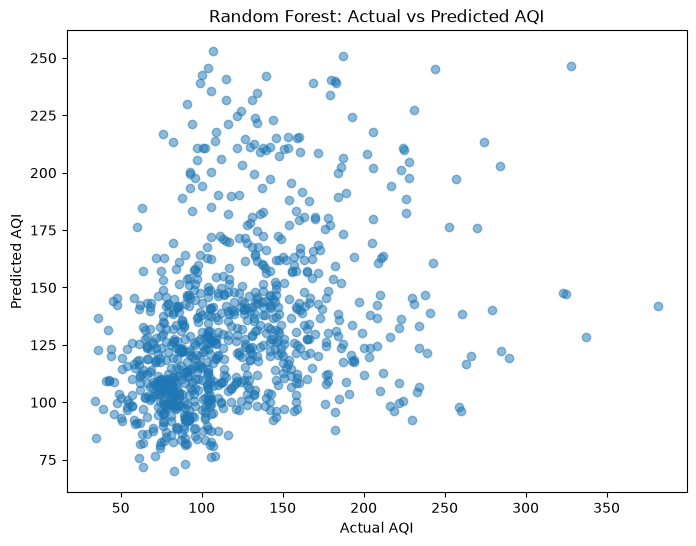

In [116]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.5
)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Random Forest: Actual vs Predicted AQI")

plt.show()

In [117]:
correlation = model_df[
    [
        "aqi_value",
        "fireCount",
        "temperature_2m_mean",
        "temperature_2m_max",
        "temperature_2m_min",
        "relative_humidity_2m_mean",
        "precipitation_sum",
        "wind_speed_10m_max",
        "surface_pressure_mean"
    ]
].corr()

print(correlation["aqi_value"].sort_values(ascending=False))

aqi_value                    1.000000
surface_pressure_mean        0.327607
fireCount                    0.273269
relative_humidity_2m_mean   -0.043169
wind_speed_10m_max          -0.074085
precipitation_sum           -0.180763
temperature_2m_max          -0.205952
temperature_2m_mean         -0.285157
temperature_2m_min          -0.350847
Name: aqi_value, dtype: float64


In [118]:
print("AQI vs Fire correlation:",
      round(model_df["aqi_value"].corr(model_df["fireCount"]), 3))

AQI vs Fire correlation: 0.273


In [119]:
print(model_df["aqi_value"].describe())

count    4500.000000
mean      120.696000
std        59.333091
min        19.000000
25%        78.000000
50%       107.000000
75%       150.000000
max       408.000000
Name: aqi_value, dtype: float64


In [120]:
print(
    "AQI > 200:",
    (model_df["aqi_value"] > 200).sum()
)

print(
    "AQI > 300:",
    (model_df["aqi_value"] > 300).sum()
)

AQI > 200: 471
AQI > 300: 55


In [121]:
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

print(importance_df.head(15))

                                 feature  importance
19                numerical__day_of_year    0.453590
14  numerical__relative_humidity_2m_mean    0.076456
12         numerical__temperature_2m_max    0.066620
17      numerical__surface_pressure_mean    0.062719
13         numerical__temperature_2m_min    0.054465
11        numerical__temperature_2m_mean    0.053241
16         numerical__wind_speed_10m_max    0.052966
10                  numerical__fireCount    0.035132
20                       numerical__year    0.023331
3             categorical__area_Ludhiana    0.023094
15          numerical__precipitation_sum    0.022783
1             categorical__area_Bathinda    0.016747
4              categorical__area_Patiala    0.015046
5             categorical__area_Rupnagar    0.012560
18                      numerical__month    0.009911


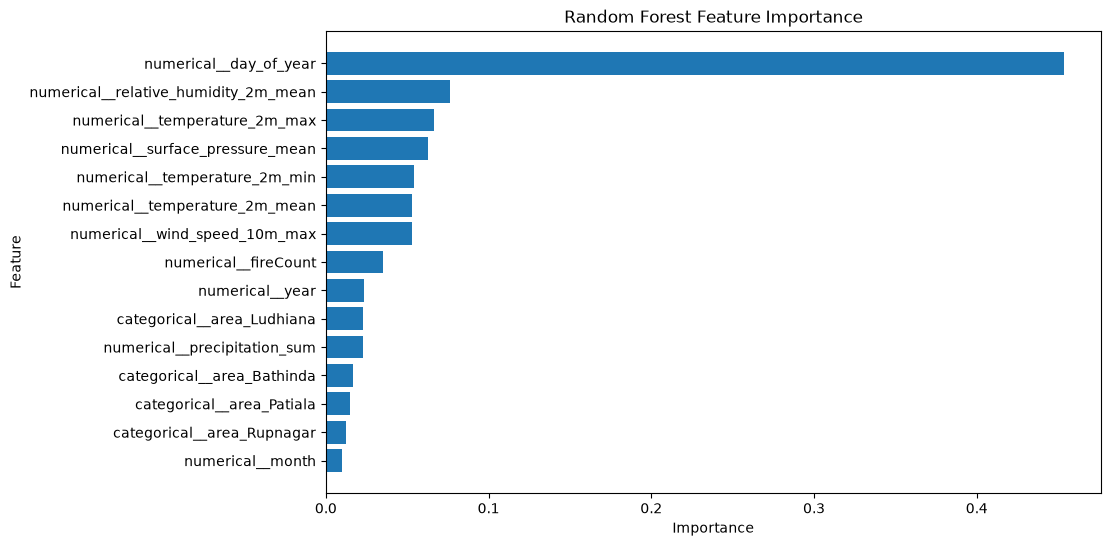

In [122]:
plt.figure(figsize=(10, 6))

top_features = importance_df.head(15).sort_values("importance")

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.show()

In [123]:
X_train_no_doy = X_train.drop(columns=["day_of_year"])
X_test_no_doy = X_test.drop(columns=["day_of_year"])

In [125]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features_no_doy = [
    "area",
    "season"
]

numerical_features_no_doy = [
    "fireCount",
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "relative_humidity_2m_mean",
    "precipitation_sum",
    "wind_speed_10m_max",
    "surface_pressure_mean",
    "month",
    "year"
]

preprocessor_no_doy = ColumnTransformer(
    transformers=[
        (
            "numerical",
            "passthrough",
            numerical_features_no_doy
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features_no_doy
        )
    ]
)

In [126]:
X_train_no_doy_processed = preprocessor_no_doy.fit_transform(
    X_train_no_doy
)

X_test_no_doy_processed = preprocessor_no_doy.transform(
    X_test_no_doy
)

print(
    "Processed X_train shape:",
    X_train_no_doy_processed.shape
)

print(
    "Processed X_test shape:",
    X_test_no_doy_processed.shape
)

Processed X_train shape: (3602, 20)
Processed X_test shape: (898, 20)


In [127]:
rf_no_doy = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_no_doy.fit(
    X_train_no_doy_processed,
    y_train
)

y_pred_no_doy = rf_no_doy.predict(
    X_test_no_doy_processed
)

In [128]:
mae_no_doy = mean_absolute_error(
    y_test,
    y_pred_no_doy
)

rmse_no_doy = np.sqrt(
    mean_squared_error(y_test, y_pred_no_doy)
)

r2_no_doy = r2_score(
    y_test,
    y_pred_no_doy
)

print("Random Forest - Without day_of_year")
print("-----------------------------------")
print("MAE :", round(mae_no_doy, 2))
print("RMSE:", round(rmse_no_doy, 2))
print("R²  :", round(r2_no_doy, 4))

Random Forest - Without day_of_year
-----------------------------------
MAE : 40.07
RMSE: 52.64
R²  : -0.1525


In [130]:
import xgboost
print(xgboost.__version__)

3.4.1


In [131]:
from xgboost import XGBRegressor

In [132]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

xgb_model.fit(
    X_train_processed,
    y_train
)

y_pred_xgb = xgb_model.predict(
    X_test_processed
)

In [133]:
xgb_mae = mean_absolute_error(
    y_test,
    y_pred_xgb
)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_xgb)
)

xgb_r2 = r2_score(
    y_test,
    y_pred_xgb
)

print("XGBoost")
print("-------")
print("MAE :", round(xgb_mae, 2))
print("RMSE:", round(xgb_rmse, 2))
print("R²  :", round(xgb_r2, 4))

XGBoost
-------
MAE : 38.26
RMSE: 50.48
R²  : -0.0598
